In [2]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle as pkl

In [3]:
#Change working directory to the location of the script
os.chdir('/home/apoorva/Desktop/MZB-new-analysis')

In [4]:
#df_Nfd = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/total_mzcounts_sorted.csv')
df_new = pd.read_csv('data/New_data/new_data_MZB.csv')
df_ont = pd.read_excel('data/New_data/20190412_MV_Bcellnumbers_ontogeny.xlsx', sheet_name='SPLEEN_Cell number')
# df_ont = pd.read_csv('data/New_data/ontogeny_counts.csv')

file_path = 'data/emperical_fit_T2.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_neutral = pkl.load(f)
else:
    raise EOFError("File is empty")

# file_path1 = 'data/New output (pkl)/Steady State/Spline_nt/SHM_T2_notransform.pkl'
# if os.path.getsize(file_path1) > 0:
#     with open(file_path1, 'rb') as f:
#         data_neutral_SHM = pkl.load(f)
# else:
#     raise EOFError("File is empty")

# file_path2 = 'data/New output (pkl)/Steady State/Spline_nt/TDM_T2_division_hill.pkl'
# if os.path.getsize(file_path2) > 0:
#     with open(file_path2, 'rb') as f:
#         data_neutral_TDD = pkl.load(f)
# else:
#     raise EOFError("File is empty")

# file_path3 = 'data/New output (pkl)/Steady State/Spline_nt/TDM_T2_influx.pkl'
# if os.path.getsize(file_path3) > 0:
#     with open(file_path3, 'rb') as f:
#         data_neutral_TDI = pkl.load(f)
# else:
#     raise EOFError("File is empty")
df_new = df_new.iloc[:-1]
# print(df_new.head(10))


/home/apoorva/Desktop/MZB-new-analysis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Keep T1 AA4.1 in the data and remove the rest 

df_T2counts_Nfd = df_new.filter(items=['Lamis.ID', 'Days postBMT', 'Age at S1K', 'total_T2'])
df_T2counts_ont = df_ont.filter(items=['mouse', 'age.at.S1K', 'Transitional2'])
# print(df_T2counts_Nfd.head(10))
print(df_T2counts_ont.head(62))

#save the data to a csv file

# df_T1counts_Nfd.to_csv('/home/apoorva/Desktop/work/MZ_analysis/data/T2counts_.csv', index=False)
# df_T1counts_ont.to_csv('/home/apoorva/Desktop/work/MZ_analysis/data/T2counts_ont.csv', index=False)



                                    mouse  age.at.S1K  Transitional2
0          Samples_Spleen_002_d11_017.fcs          11   2.731288e+06
1          Samples_Spleen_003_d11_018.fcs          11   2.122800e+06
2          Samples_Spleen_004_d11_019.fcs          11   2.362542e+06
3          Samples_Spleen_005_d11_020.fcs          11   2.149343e+06
4          Samples_Spleen_006_d14_021.fcs          14   6.346286e+06
..                                    ...         ...            ...
57       X20190201_Spleen_57d_006_016.fcs          57   3.511686e+06
58      X20180907_TH283_Bcells_SP_002.fcs          71   2.284950e+06
59      X20181023_MV60_Bcells_SPL_001.fcs         113   1.691688e+06
60  X20181120_MV60_d26_SPLEEN_006_021.fcs         152   1.223985e+06
61  X20181120_MV60_d26_SPLEEN_007_022.fcs         152   3.353367e+06

[62 rows x 3 columns]


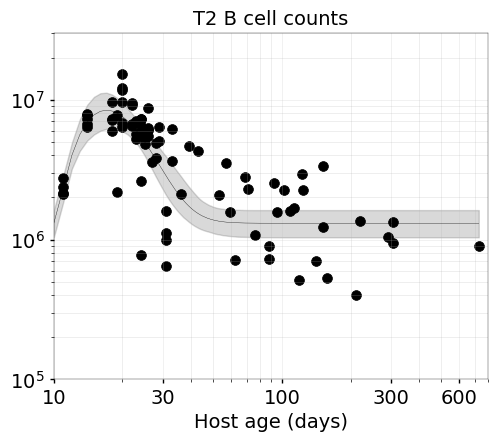

In [6]:

# Plot T2 counts

t_ev =np.array(np.arange(10,731,1))
fig = plt.figure(figsize=(5.6, 4.5))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_T2', s=50, color='black', edgecolor='black', linewidth=0.5,legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='Transitional2', s=50, color = 'black', edgecolor='black', linewidth=0.5, legend=False)
plt.plot(t_ev, np.mean(data_neutral.T2_counts_pred, axis=0),  color= 'black',  linewidth=0.25)
plt.fill_between(t_ev, np.quantile(data_neutral.T2_counts_pred, 0.025, axis=0), np.quantile(data_neutral.T2_counts_pred, 0.975, axis=0),  color = 'black', alpha=0.15)
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e5, 3*1e7)
plt.xlim(10, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30,  100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Host age (days)', fontsize=14)
plt.ylabel('')
plt.title('T2 B cell counts', fontsize=14)
# Axis border width
for spine in plt.gca().spines.values():
    spine.set_linewidth(0.25)   # try 0.6 / 0.8 / 1.0

# Tick mark width
plt.tick_params(axis='both', which='both', width=0.8)
plt.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
plt.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
plt.tick_params(axis="both", labelsize=14)

# tick mark size and thickness
plt.tick_params(axis="both", which="major", length=3, width=1)
plt.tick_params(axis="both", which="minor", length=2, width=0.5)
# no legend
plt.legend([],[], frameon=False)
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)


# save the figure
plt.savefig('T2_precursor.pdf', dpi=300)
plt.show()


In [7]:
print(np.mean(data_neutral.theta_0))
print(np.mean(data_neutral.nu))
print(np.mean(data_neutral.n))

14.0779638875
0.2493505370625
1.761274893625


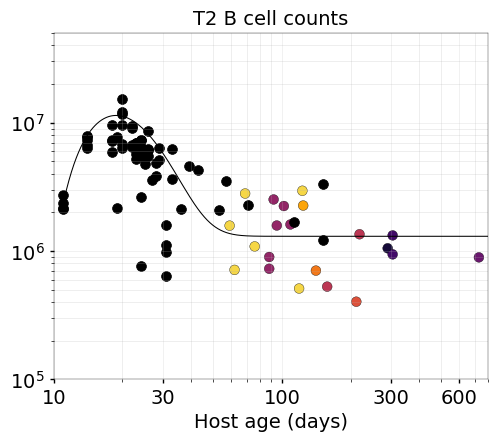

In [11]:
def P(t):
    theta_0 = np.exp(14.08)
    nu = 0.2
    n = 1.75
    # # return theta_0 * (1 + (t-11)**n * np.exp(-nu * (t-11)))
    # return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
    # theta_0 = np.exp(14.12)
    # nu = 0.264
    # # n = 1.96
    # return theta_0 * (1 + (t-11)**n * np.exp(-nu * (t-11)))
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
    
col_pal = sns.color_palette("inferno", n_colors=len(df_new['Age at BMT'].unique()))
col_pal = col_pal[::-1]

# Plot T2 counts

fig = plt.figure(figsize=(5.6, 4.5))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_T2', hue='Age at BMT', palette=col_pal, s=50, edgecolor='black', linewidth=0.25, legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='Transitional2', s=50, color = 'black', edgecolor='black', linewidth=0.5, legend=False)
plt.plot(np.arange(11, 800, 0.05), P(np.arange(11, 800, 0.05)), color= 'black',  linewidth=0.75)
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e5, 5*1e7)
plt.xlim(10, 800)
plt.xticks([10, 30,  100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Host age (days)', fontsize=14)
plt.title('T2 B cell counts', fontsize=14)
plt.ylabel('')
# Axis border width
for spine in plt.gca().spines.values():
    spine.set_linewidth(0.25)   # try 0.6 / 0.8 / 1.0

# Tick mark width
plt.tick_params(axis='both', which='both', width=0.8)
plt.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
plt.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
plt.tick_params(axis="both", labelsize=14)

# tick mark size and thickness
plt.tick_params(axis="both", which="major", length=3, width=1)
plt.tick_params(axis="both", which="minor", length=2, width=0.5)
# no legend
plt.legend([],[], frameon=False)
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)


# save the figure
plt.savefig('T2_precursor.pdf', dpi=300)
plt.show()


In [9]:
def P(t):
    theta_0 = np.exp(np.mean(data_neutral.theta_0))
    nu = np.mean(data_neutral.nu)
    n = np.mean(data_neutral.n)
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
   
 
# Define the ODE function
def ode_function(t, M, phi, rho, delta, P):
    dMdt = phi * P(t) - (delta - rho) * M
    return np.array(dMdt)


# Define the parameters as array
phi = data_neutral_SHM.stan_variable('phi')
rho = data_neutral_SHM.stan_variable('rho')
M_stable = data_neutral_SHM.stan_variable('MZ_counts_pred1')


delta = ((phi * 1308516) / M_stable[:,0] ) + rho


#Initial conditions at time t=40
M0 = [12058]


t_ev = np.arange(11, 750, 0.001)

sol = np.zeros((len(data_neutral_SHM.phi), len(t_ev)))
for i in range(len(data_neutral_SHM.phi)):
    result = solve_ivp(ode_function, [11, 750], M0, t_eval= t_ev, args=(phi[i], rho[i], delta[i], P))
    sol[i, :] = result.y[0]

print(sol.shape)



NameError: name 'data_neutral_SHM' is not defined

/tmp/ipykernel_801246/1652925588.py:10: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


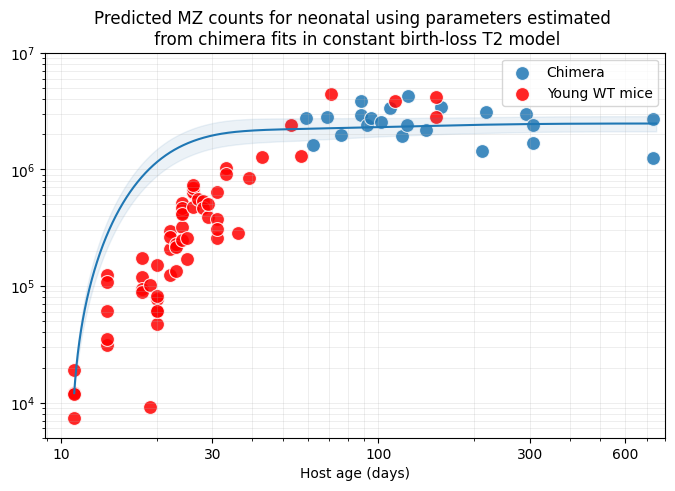

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
plt.plot(t_ev, np.mean(sol, axis=0))
plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.1)
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Host age (days)')
plt.ylabel('')
plt.title('Predicted MZ counts for neonatal using parameters estimated \n from chimera fits in constant birth-loss T2 model')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()

#save the figure
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Ontogeny predictions/SHM_T2.png', dpi=300)
plt.show()



In [ ]:
def P(t):
    theta_0 = np.exp(np.mean(data_neutral.theta_0))
    nu = np.mean(data_neutral.nu)
    n = np.mean(data_neutral.n)
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))


def rho_func(t, rho_var, r_d_val):
    return rho_var / (1 + t/r_d_val) 



def delta_func(t, phi_val, rho_val, r_d_val, mz_counts_val):
    delta = ((phi_val * 1308516) / mz_counts_val) + (rho_val / (1 + t / r_d_val))
    return delta

# Define the ODE function
def ode_function(t, M, phi_val, rho_val, r_d_val, mz_counts_val, P):
    rho_t = rho_func(t, rho_val, r_d_val)
    delta_t = delta_func(t, phi_val, rho_val, r_d_val, mz_counts_val)
    dMdt = phi_val * P(t) - (delta_t - rho_t) * M
    return np.array(dMdt)

#Initial conditions at time t=11
M0 = [12058]

t_ev = np.arange(11, 750, 0.001)

phi = data_neutral.stan_variable('phi')  #Influx rate
rho_values = data_neutral.stan_variable('rho')  # Extract 'rho' values from CmdStanMCMC object
r_d_values = data_neutral.stan_variable('r_d')  # Extract 'r_d' values from CmdStanMCMC object
mz_counts = data_neutral.stan_variable('MZ_counts_pred1')[:,0]

sol1 = np.zeros((len(rho_values), len(t_ev)))
for i in range(len(rho_values)):
    result = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev,
                       args=(phi[i], rho_values[i], r_d_values[i], mz_counts[i], P))
    sol1[i, :] = result.y[0]



/tmp/ipykernel_801246/2480932357.py:12: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


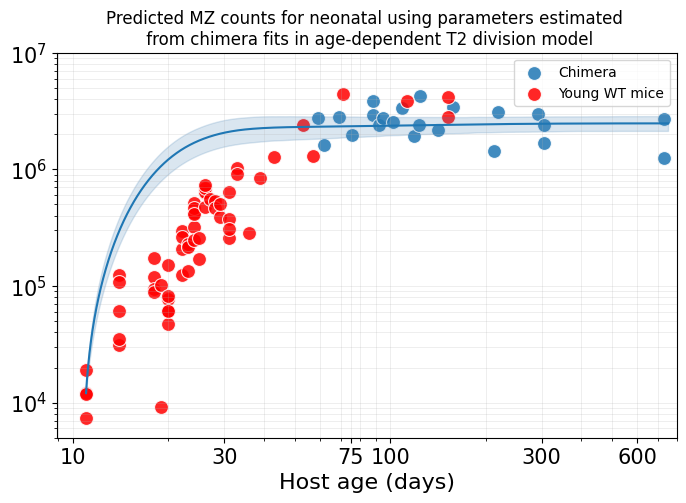

In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
# plt.plot(t_ev, sol.y[0], label='Predicted trajectory')
plt.plot(t_ev, np.mean(sol1, axis=0))
plt.fill_between(t_ev, np.quantile(sol1, 0.025, axis=0), np.quantile(sol1, 0.975, axis=0), color = 'steelblue',alpha=0.2)
# plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 75, 100, 300, 600], [10, 30, 75, 100, 300, 600])
plt.xlabel('Host age (days)', fontsize=16)
plt.ylabel('')
plt.tick_params(axis='both', labelsize=15)
plt.title('Predicted MZ counts for neonatal using parameters estimated \n from chimera fits in age-dependent T2 division model')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Ontogeny predictions/TDM_division_T2.png', dpi=300)
plt.show()

In [ ]:
def P(t):
    theta_0 = np.exp(np.mean(data_neutral.theta_0))
    nu = np.mean(data_neutral.nu)
    n = np.mean(data_neutral.n)
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))


def phi_func(t, phi, r_d_val):
    return phi * np.exp(-r_d_val * (t-40))



def delta_func(t, phi, rho_val, r_d_val, mz_counts):
    delta = (((phi * np.exp(-r_d_val * (t-40))) * 1308516) / mz_counts) + rho_val
    return delta

# Define the ODE function
def ode_function(t, M, phi, rho_val, r_d_val, mz_counts, P):
    phi_t = phi_func(t, phi, r_d_val)
    delta_t = delta_func(t, phi_t, rho_val, r_d_val, mz_counts)
    dMdt = phi_t * P(t) - (delta_t - rho_val) * M
    return np.array(dMdt)

#Initial conditions at time t=11
M0 = [12058]

t_ev = np.arange(11, 750, 0.001)

phi = data_neutral.stan_variable('phi')  #Influx rate
rho_val = data_neutral.stan_variable('rho')  # Extract 'rho' values from CmdStanMCMC object
r_d_val = data_neutral.stan_variable('r_d')  # Extract 'r_d' values from CmdStanMCMC object
mz_counts = data_neutral.stan_variable('MZ_counts_pred1')[:,0]

sol2 = np.zeros((len(rho_val), len(t_ev)))
for i in range(len(rho_val)):
    result = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev,
                       args=(phi[i], rho_val[i], r_d_val[i], mz_counts[i], P))
    sol2[i, :] = result.y[0]


/tmp/ipykernel_801246/3295205795.py:12: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


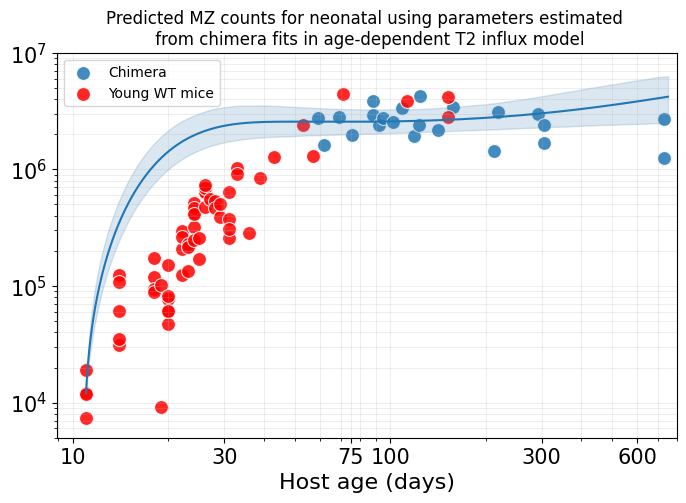

In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
# plt.plot(t_ev, sol.y[0], label='Predicted trajectory')
plt.plot(t_ev, np.mean(sol2, axis=0))
plt.fill_between(t_ev, np.quantile(sol2, 0.025, axis=0), np.quantile(sol2, 0.975, axis=0), color = 'steelblue',alpha=0.2)
# plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 75, 100, 300, 600], [10, 30, 75, 100, 300, 600])
plt.xlabel('Host age (days)', fontsize=16)
plt.ylabel('')
plt.tick_params(axis='both', labelsize=15)
plt.title('Predicted MZ counts for neonatal using parameters estimated \n from chimera fits in age-dependent T2 influx model')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Ontogeny predictions/TDM_influx_T2.png', dpi=300)
plt.show()